In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set beautiful styling for the plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# 1. Load Data
data_klaim = pd.read_csv('data/Data_Klaim.csv')
data_polis = pd.read_csv('data/Data_Polis.csv')

# 2. Clean and Merge
data_klaim = data_klaim[data_klaim['Status Klaim'] == 'PAID'].copy()
data_klaim['Tanggal Pasien Masuk RS'] = pd.to_datetime(data_klaim['Tanggal Pasien Masuk RS'])
data_polis['Tanggal Lahir'] = pd.to_datetime(data_polis['Tanggal Lahir'])

# Merge on Nomor Polis
df_merged = pd.merge(data_klaim, data_polis, on='Nomor Polis', how='inner')

# Feature Engineering for Visuals
df_merged['Month_Year'] = df_merged['Tanggal Pasien Masuk RS'].dt.to_period('M')

# >>> THE FIX: Calculate days, divide by 365.25, and turn into a clean integer <<<
df_merged['Age_At_Claim'] = ((df_merged['Tanggal Pasien Masuk RS'] - df_merged['Tanggal Lahir']).dt.days / 365.25).astype(int)

# Create Age Groups
bins = [0, 18, 30, 45, 60, 100]
labels = ['0-18', '19-30', '31-45', '46-60', '60+']
df_merged['Age_Group'] = pd.cut(df_merged['Age_At_Claim'], bins=bins, labels=labels)

print("Data successfully merged and cleaned! Total rows:", len(df_merged))

Data successfully merged and cleaned! Total rows: 4627


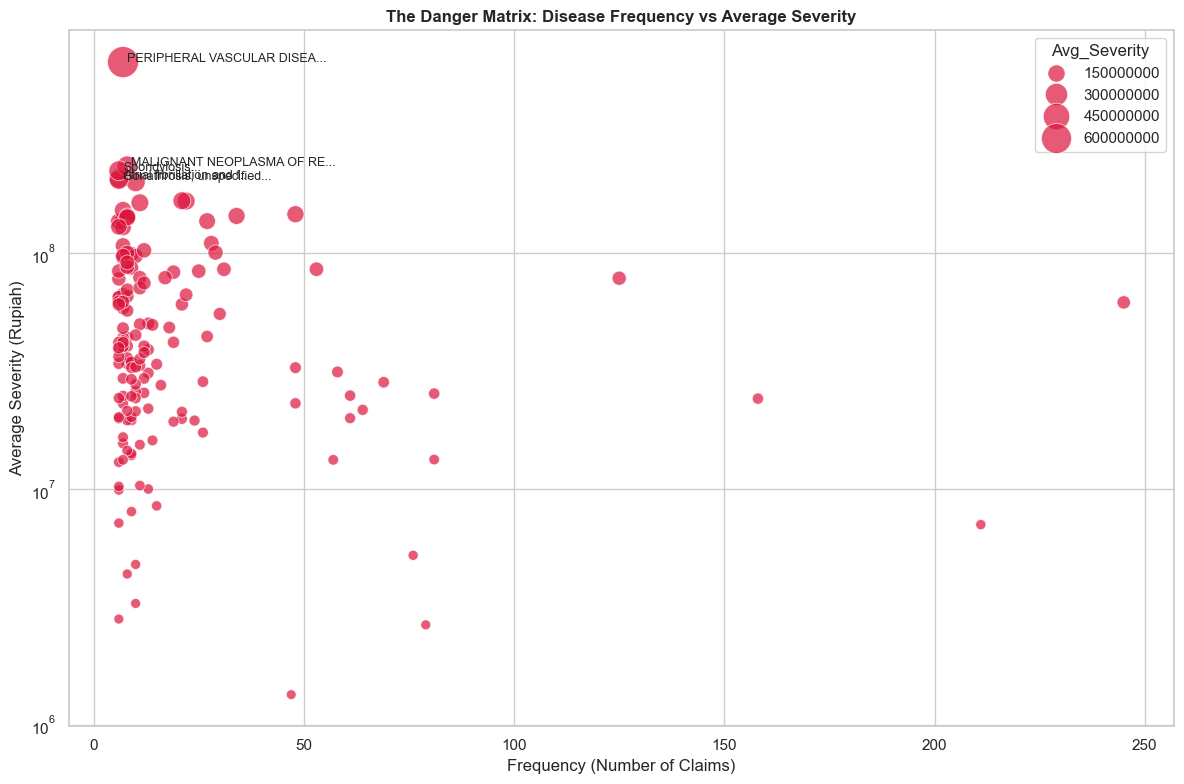

In [5]:
# Aggregate by ICD Description
icd_stats = df_merged.groupby('ICD Description').agg(
    Frequency=('Claim ID', 'count'),
    Avg_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

# Filter out extremely rare ones for a cleaner chart
icd_stats = icd_stats[icd_stats['Frequency'] > 5]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=icd_stats, x='Frequency', y='Avg_Severity', size='Avg_Severity', 
                sizes=(50, 500), alpha=0.7, color='crimson')

# Add labels to the most dangerous diseases (Top 5 by Severity)
top_severe = icd_stats.nlargest(5, 'Avg_Severity')
for i, row in top_severe.iterrows():
    plt.text(row['Frequency'] + 1, row['Avg_Severity'], row['ICD Description'][:25] + '...', fontsize=9)

plt.title('The Danger Matrix: Disease Frequency vs Average Severity', fontweight='bold')
plt.xlabel('Frequency (Number of Claims)')
plt.ylabel('Average Severity (Rupiah)')
plt.yscale('log') # Log scale because severity can vary wildly
plt.tight_layout()
plt.show()

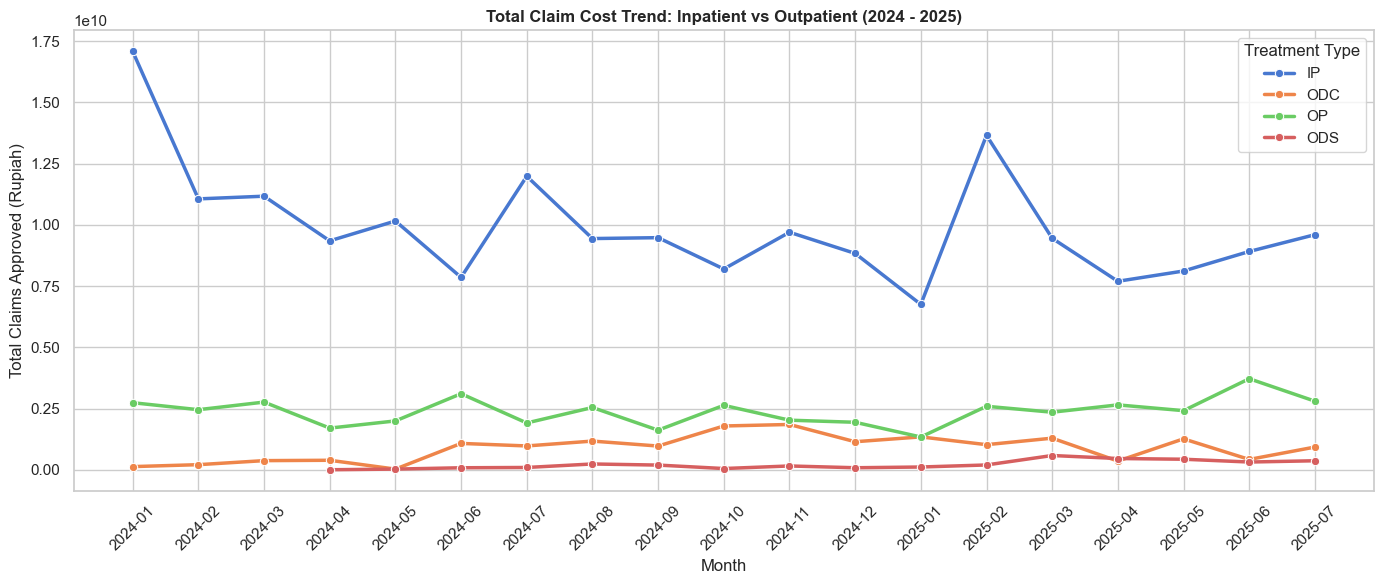

In [6]:
trend_data = df_merged.groupby(['Month_Year', 'Inpatient/Outpatient'])['Nominal Klaim Yang Disetujui'].sum().reset_index()
trend_data['Month_Year'] = trend_data['Month_Year'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_data, x='Month_Year', y='Nominal Klaim Yang Disetujui', 
             hue='Inpatient/Outpatient', marker='o', linewidth=2.5)

plt.title('Total Claim Cost Trend: Inpatient vs Outpatient (2024 - 2025)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Claims Approved (Rupiah)')
plt.xticks(rotation=45)
plt.legend(title='Treatment Type')
plt.tight_layout()
plt.show()

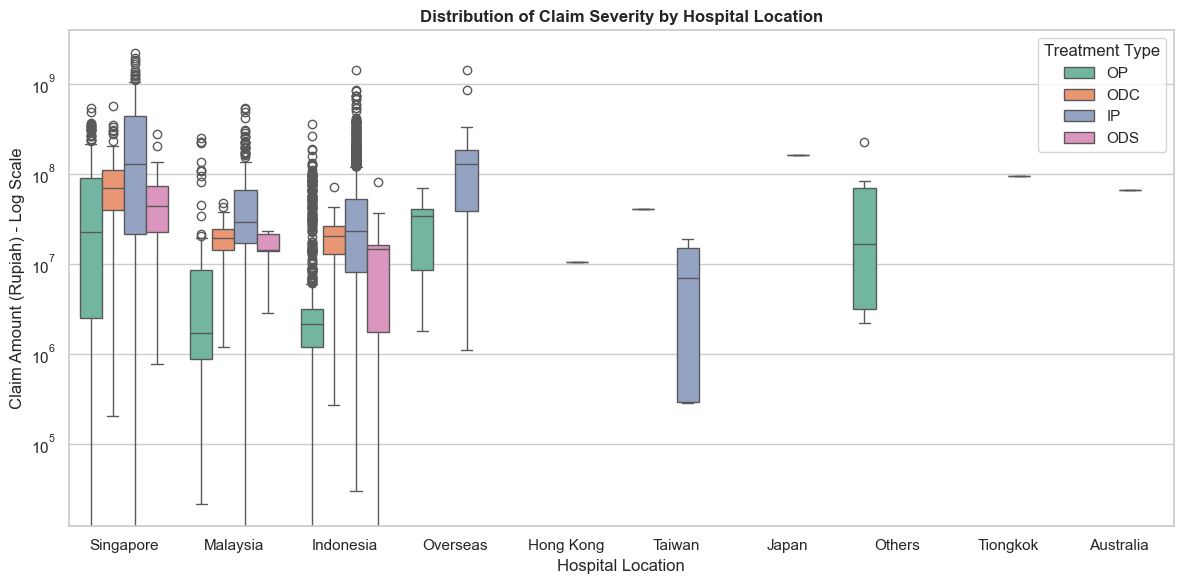

In [7]:
plt.figure(figsize=(12, 6))
# Using a boxplot with a log-scale on the Y-axis to handle the massive outliers safely
sns.boxplot(data=df_merged, x='Lokasi RS', y='Nominal Klaim Yang Disetujui', 
            hue='Inpatient/Outpatient', palette='Set2')

plt.title('Distribution of Claim Severity by Hospital Location', fontweight='bold')
plt.xlabel('Hospital Location')
plt.ylabel('Claim Amount (Rupiah) - Log Scale')
plt.yscale('log')
plt.xticks(rotation=0)
plt.legend(title='Treatment Type', loc='upper right')
plt.tight_layout()
plt.show()

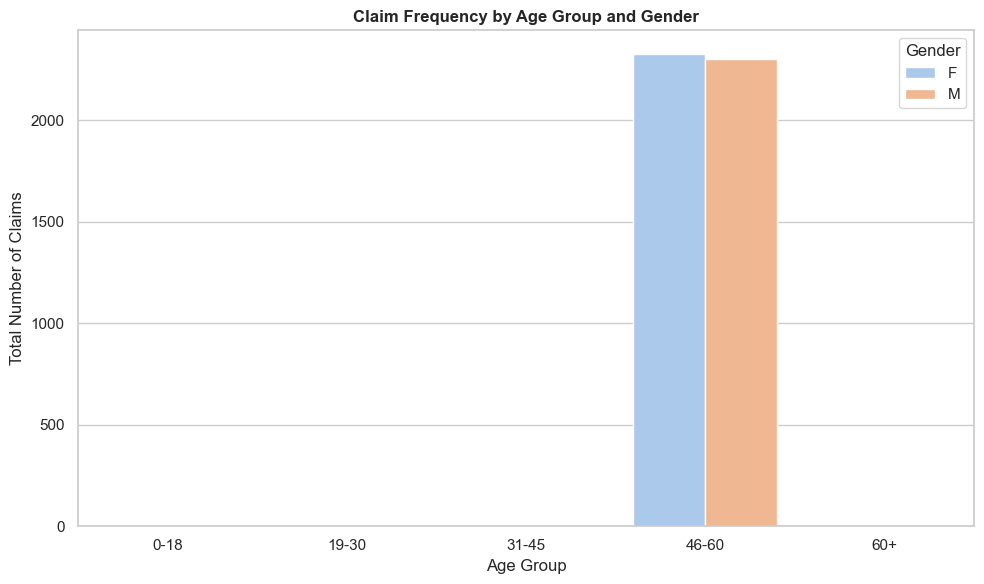

In [8]:
age_gender_stats = df_merged.groupby(['Age_Group', 'Gender'])['Claim ID'].count().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=age_gender_stats, x='Age_Group', y='Claim ID', hue='Gender', palette='pastel')

plt.title('Claim Frequency by Age Group and Gender', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Total Number of Claims')
plt.tight_layout()
plt.show()

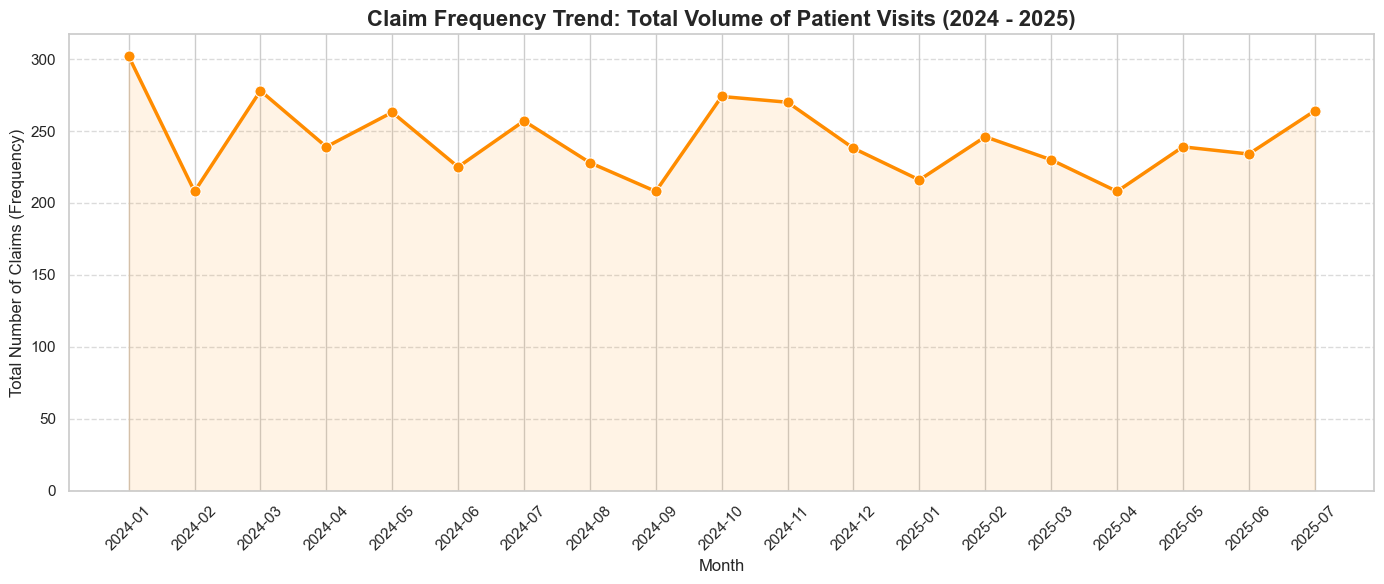

In [9]:
# 1. Aggregate the total number of claims per month
freq_trend = df_merged.groupby('Month_Year')['Claim ID'].count().reset_index()
freq_trend.rename(columns={'Claim ID': 'Frequency'}, inplace=True)

# Convert Period object to string so Seaborn can plot it beautifully
freq_trend['Month_Year'] = freq_trend['Month_Year'].astype(str)

# 2. Plotting
plt.figure(figsize=(14, 6))

# Draw the main trend line
sns.lineplot(data=freq_trend, x='Month_Year', y='Frequency', 
             marker='o', markersize=8, color='darkorange', linewidth=2.5)

# Fill the area under the line for a polished, "Grandmaster" dashboard look
plt.fill_between(freq_trend['Month_Year'], freq_trend['Frequency'], 
                 color='darkorange', alpha=0.1)

# Formatting
plt.title('Claim Frequency Trend: Total Volume of Patient Visits (2024 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Number of Claims (Frequency)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Start y-axis at 0 so the visual scale isn't exaggerated
plt.ylim(bottom=0) 

plt.tight_layout()
plt.show()